# Choice-Based Conjoint Analysis: Truffles

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import stats
from statsmodels.graphics.mosaicplot import mosaic

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

## Idea of the Multinomial Logit Model

In [7]:
# Conceptual example: deterministic utility v, random utility u, choice and probabilities
alpha, beta = 0.5, -0.01
error1, error2, error3 = np.random.gumbel(size=3)

v1 = alpha * 4 + beta * 100
v2 = alpha * 5 + beta * 150
v3 = alpha * 2 + beta * 175

u1 = v1 + error1
u2 = v2 + error2
u3 = v3 + error3

choice = int(np.argmax([u1, u2, u3])) + 1

p1 = np.exp(v1) / (np.exp(v1) + np.exp(v2) + np.exp(v3))
p2 = np.exp(v2) / (np.exp(v1) + np.exp(v2) + np.exp(v3))
p3 = np.exp(v3) / (np.exp(v1) + np.exp(v2) + np.exp(v3))
choice, p1, p2, p3

(2, 0.4600294354493428, 0.4600294354493428, 0.0799411291013143)

## Data Loading

In [10]:
# Read the CBC choice data (long format)
CBCData = pd.read_excel('CBC_truffles_data.xlsx', sheet_name='CBC_truffles_data')
CBCData.head()

,Respondent,id,Set,alt,choice,NONE,Fruity,Nutty,Mixed,Creamy,Liquid,Price5.99,Price6.99,Price7.99,Price,YesSuperfoods,Size15g,Size10g,Size20g,Size5g
0,Person1,1,1,1,0,0,1,0,0,1,0,0,0,1,7.99,1,0,0,0,1
1,Person1,1,1,2,0,0,0,0,1,1,0,1,0,0,5.99,1,0,1,0,0
2,Person1,1,1,3,1,0,0,1,0,0,1,0,1,0,6.99,0,1,0,0,0
3,Person1,1,1,4,0,1,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0
4,Person1,1,2,1,0,0,0,1,0,1,0,1,0,0,5.99,1,0,0,0,1


## Descriptive Statistics

In [15]:
# Counts and share of 'None' choices
num_respondents = CBCData['id'].nunique()
num_choice_sets = CBCData['Set'].nunique()
num_alternatives = CBCData['alt'].nunique()
none_chosen_percent = CBCData.loc[CBCData['choice'] == 1, 'NONE'].mean() * 100

{'Respondents': num_respondents,
 'ChoiceSets': num_choice_sets,
 'Alternatives': num_alternatives,
 'NoneChosenPercent': none_chosen_percent}

{'Respondents': 44,
 'ChoiceSets': 24,
 'Alternatives': 4,
 'NoneChosenPercent': 19.71563981042654}

In [17]:
# Total number of choices made
total_choices = num_respondents * num_choice_sets
total_choices

1056

## Cross-tabulations of Price and Choice

In [20]:
# Counts of rows by Price x choice
pd.crosstab(CBCData['Price'], CBCData['choice'])

choice,0,1
Price,,
0.00,847,208
5.99,617,438
6.99,764,291
7.99,937,118


In [22]:
# Absolute frequency: number chosen by Price (weighting by choice)
pd.crosstab(CBCData['Price'], CBCData['choice'], values=CBCData['choice'], aggfunc='sum').fillna(0)

choice,0,1
Price,,
0.00,0,208
5.99,0,438
6.99,0,291
7.99,0,118


In [24]:
# Relative frequency of chosen alternatives by Price
chosen_by_price = CBCData.groupby('Price')['choice'].sum()
chosen_by_price / chosen_by_price.sum()

Price
0.00    0.197156
5.99    0.415166
6.99    0.275829
7.99    0.111848
Name: choice, dtype: float64

## Mosaic Plots

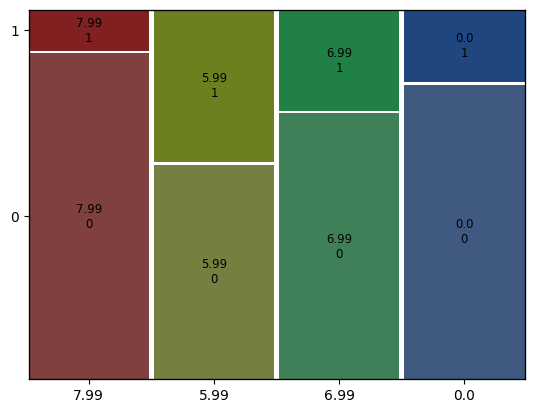

In [27]:
mosaic(CBCData, ['Price', 'choice'], gap=0.01)
plt.show()

## Prepare Data for the Multinomial Logit Model

In [32]:
# Each (id, Set) is one choice situation; build a grouping key like mlogit.data
choice_data = CBCData.copy()
choice_data['cs'] = choice_data['id'].astype(str) + '_' + choice_data['Set'].astype(str)
choice_data.head()

,Respondent,id,Set,alt,choice,NONE,Fruity,Nutty,Mixed,Creamy,Liquid,Price5.99,Price6.99,Price7.99,Price,YesSuperfoods,Size15g,Size10g,Size20g,Size5g,cs
0,Person1,1,1,1,0,0,1,0,0,1,0,0,0,1,7.99,1,0,0,0,1,1_1
1,Person1,1,1,2,0,0,0,0,1,1,0,1,0,0,5.99,1,0,1,0,0,1_1
2,Person1,1,1,3,1,0,0,1,0,0,1,0,1,0,6.99,0,1,0,0,0,1_1
3,Person1,1,1,4,0,1,0,0,0,0,0,0,0,0,0.00,0,0,0,0,0,1_1
4,Person1,1,2,1,0,0,0,1,0,1,0,1,0,0,5.99,1,0,0,0,1,1_2


## Conditional Logit Estimator
Replicates `mlogit(choice ~ -1 + ...)`: utility is linear in the alternative attributes, probabilities are softmax within each choice situation.

In [35]:
class MNLResult:
    def __init__(self, names, coef, se, ll, ll0, nobs):
        self.names, self.coef, self.se = names, coef, se
        self.ll, self.ll0, self.nobs = ll, ll0, nobs
        self.params = pd.Series(coef, index=names)
    def summary(self):
        z = self.coef / self.se
        p = 2 * (1 - stats.norm.cdf(np.abs(z)))
        tbl = pd.DataFrame({'Estimate': self.coef, 'Std. Error': self.se,
                            'z-value': z, 'Pr(>|z|)': p}, index=self.names)
        print(tbl.to_string())
        print(f'\nLog-Likelihood: {self.ll:.1f}')
        return tbl

def fit_mnl(data, varlist, group='cs', choice='choice'):
    X = data[varlist].to_numpy(float)
    y = data[choice].to_numpy(float)
    _, inv = np.unique(data[group].to_numpy(), return_inverse=True)
    def negll(b):
        ev = np.exp(X @ b)
        denom = np.bincount(inv, weights=ev)[inv]
        return -np.sum(y * np.log(ev / denom))
    b0 = np.zeros(len(varlist))
    res = minimize(negll, b0, method='BFGS')
    b = res.x
    # Standard errors from the numerical Hessian of the negative log-likelihood
    def grad(b, eps=1e-5):
        g = np.empty_like(b)
        for i in range(len(b)):
            d = np.zeros_like(b); d[i] = eps
            g[i] = (negll(b + d) - negll(b - d)) / (2 * eps)
        return g
    n = len(b); H = np.empty((n, n)); eps = 1e-5
    for i in range(n):
        d = np.zeros(n); d[i] = eps
        H[:, i] = (grad(b + d) - grad(b - d)) / (2 * eps)
    H = (H + H.T) / 2
    se = np.sqrt(np.diag(np.linalg.inv(H)))
    n_cs = len(np.unique(inv))
    ll0 = -n_cs * np.log(data.groupby(group).size().iloc[0])
    return MNLResult(list(varlist), b, se, -res.fun, ll0, n_cs)

## Main Model 

In [38]:
# choice -1 + NONE + Nutty + Mixed + Liquid + YesSuperfoods + Size10g + Size20g + Size5g + Price
vars_mnl1 = ['NONE', 'Nutty', 'Mixed', 'Liquid', 'YesSuperfoods',
             'Size10g', 'Size20g', 'Size5g', 'Price']
mnl1 = fit_mnl(choice_data, vars_mnl1)
_ = mnl1.summary()

               Estimate  Std. Error    z-value  Pr(>|z|)
NONE          -4.786417    0.366647 -13.054569  0.000000
Nutty          0.454119    0.094218   4.819878  0.000001
Mixed         -0.115632    0.105511  -1.095928  0.273110
Liquid        -0.060685    0.081086  -0.748411  0.454212
YesSuperfoods  0.753864    0.082205   9.170518  0.000000
Size10g       -0.180128    0.103153  -1.746226  0.080772
Size20g       -1.995857    0.162408 -12.289178  0.000000
Size5g        -0.273295    0.106690  -2.561575  0.010420
Price         -0.675999    0.052426 -12.894271  0.000000

Log-Likelihood: -1178.1


## Restricted Model `mnl0`

In [41]:
# choice  -1 + NONE + Price
mnl0 = fit_mnl(choice_data, ['NONE', 'Price'])
_ = mnl0.summary()

       Estimate  Std. Error    z-value  Pr(>|z|)
NONE  -4.383828    0.313123 -14.000338       0.0
Price -0.600129    0.045887 -13.078450       0.0

Log-Likelihood: -1361.0


## Likelihood-Ratio Test (mnl0 vs mnl1)

In [44]:
# LR = 2 * (LL_full - LL_restricted), df = difference in number of parameters
LR = 2 * (mnl1.ll - mnl0.ll)
df = len(mnl1.coef) - len(mnl0.coef)
p_value = 1 - stats.chi2.cdf(LR, df)
{'Chisq': LR, 'Df': df, 'Pr(>Chisq)': p_value}

{'Chisq': 365.73527923216807, 'Df': 7, 'Pr(>Chisq)': 0.0}

## Price-only Model with Intercepts

In [47]:
# choice price (alternative-specific intercepts for alt 2,3,4)
d18 = choice_data.copy()
for a in [2, 3, 4]:
    d18[f'alt{a}'] = (d18['alt'] == a).astype(int)
mnl = fit_mnl(d18, ['alt2', 'alt3', 'alt4', 'Price'])
_ = mnl.summary()

       Estimate  Std. Error    z-value      Pr(>|z|)
alt2   0.485039    0.096540   5.024234  5.054467e-07
alt3   0.573723    0.091343   6.280986  3.364318e-10
alt4  -4.355043    0.320098 -13.605364  0.000000e+00
Price -0.651086    0.047852 -13.606269  0.000000e+00

Log-Likelihood: -1338.5


## Attributes Table

In [53]:
attributes = pd.DataFrame({
    'var': ['NONE', 'Fruity', 'Nutty', 'Mixed', 'Creamy', 'Liquid',
            'NoSuperfoods', 'YesSuperfoods', 'Size5g', 'Size10g', 'Size15g', 'Size20g', 'Price'],
    'attr': [''] + ['Flavor']*3 + ['Filling']*2 + ['Superfoods']*2 + ['Size']*4 + ['Price'],
    'order': range(1, 14)
})
attributes

,var,attr,order
0,NONE,,1
1,Fruity,Flavor,2
2,Nutty,Flavor,3
3,Mixed,Flavor,4
4,Creamy,Filling,5
5,Liquid,Filling,6
6,NoSuperfoods,Superfoods,7
7,YesSuperfoods,Superfoods,8
8,Size5g,Size,9
9,Size10g,Size,10


## Part-Worth Utilities

In [56]:
est = pd.DataFrame({'var': mnl1.names, 'est': mnl1.coef})
Partworth = (attributes.merge(est, on='var', how='left')
             .sort_values('order')
             .assign(est=lambda d: d['est'].fillna(0)))
Partworth['mean_est'] = Partworth.groupby('attr')['est'].transform('mean')
Partworth['PartWorth'] = Partworth['est'] - Partworth['mean_est']
Partworth.loc[Partworth['attr'] == 'Price', 'PartWorth'] = Partworth['est']
Partworth

,var,attr,order,est,mean_est,PartWorth
0,NONE,,1,-4.786417,-4.786417,0.000000
1,Fruity,Flavor,2,0.000000,0.112829,-0.112829
2,Nutty,Flavor,3,0.454119,0.112829,0.341290
3,Mixed,Flavor,4,-0.115632,0.112829,-0.228461
4,Creamy,Filling,5,0.000000,-0.030343,0.030343
5,Liquid,Filling,6,-0.060685,-0.030343,-0.030343
6,NoSuperfoods,Superfoods,7,0.000000,0.376932,-0.376932
7,YesSuperfoods,Superfoods,8,0.753864,0.376932,0.376932
8,Size5g,Size,9,-0.273295,-0.612320,0.339025
9,Size10g,Size,10,-0.180128,-0.612320,0.432192


## Plot Part-Worth Utilities

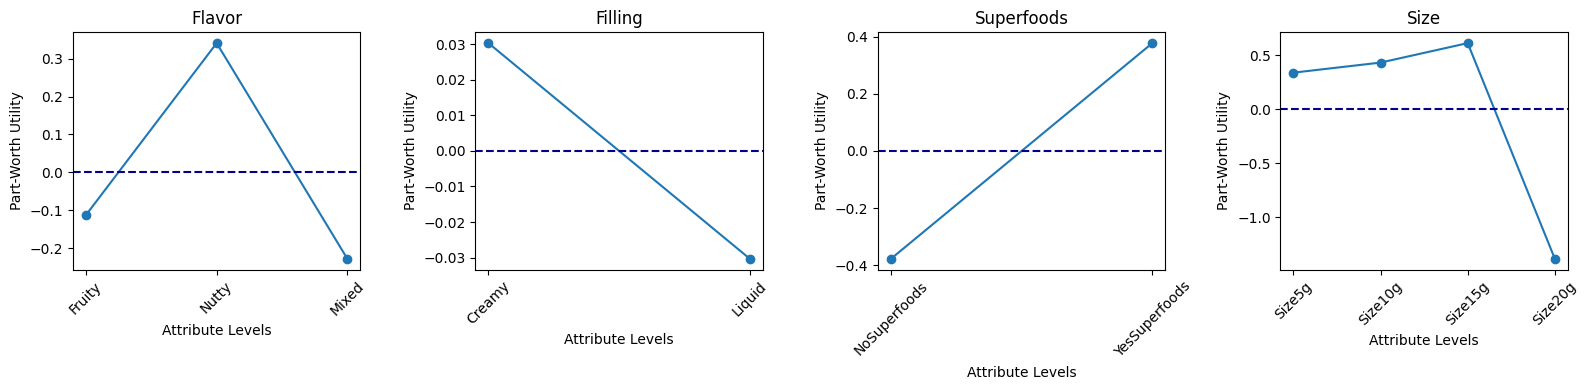

In [59]:
sub = Partworth[Partworth['attr'].isin(['Flavor', 'Filling', 'Superfoods', 'Size'])]
groups = ['Flavor', 'Filling', 'Superfoods', 'Size']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, g in zip(axes, groups):
    s = sub[sub['attr'] == g].sort_values('order')
    ax.plot(s['var'], s['PartWorth'], marker='o')
    ax.axhline(0, ls='--', color='darkblue')
    ax.set_title(g); ax.set_xlabel('Attribute Levels'); ax.set_ylabel('Part-Worth Utility')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

## Relative Attribute Importance (RAI)

In [62]:
def attr_range(d):
    if d['attr'].iloc[0] == 'Price':
        return abs(d['est'].iloc[0]) * 2
    return d['PartWorth'].max() - d['PartWorth'].min()

rng = (Partworth[Partworth['attr'] != '']
       .groupby('attr').apply(attr_range).rename('range').reset_index())
rng['sum_range'] = rng['range'].sum()
rng['RAI'] = rng['range'] / rng['sum_range']
RAI = rng
RAI

C:\Users\rgala\AppData\Local\Temp\ipykernel_36752\3157477670.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .groupby('attr').apply(attr_range).rename('range').reset_index())


,attr,range,sum_range,RAI
0,Filling,0.060685,4.732155,0.012824
1,Flavor,0.569751,4.732155,0.120400
2,Price,1.351997,4.732155,0.285704
3,Size,1.995857,4.732155,0.421765
4,Superfoods,0.753864,4.732155,0.159307


The RAI values sum to 1.

In [64]:
RAI['RAI'].sum()

1.0

## Plot RAI

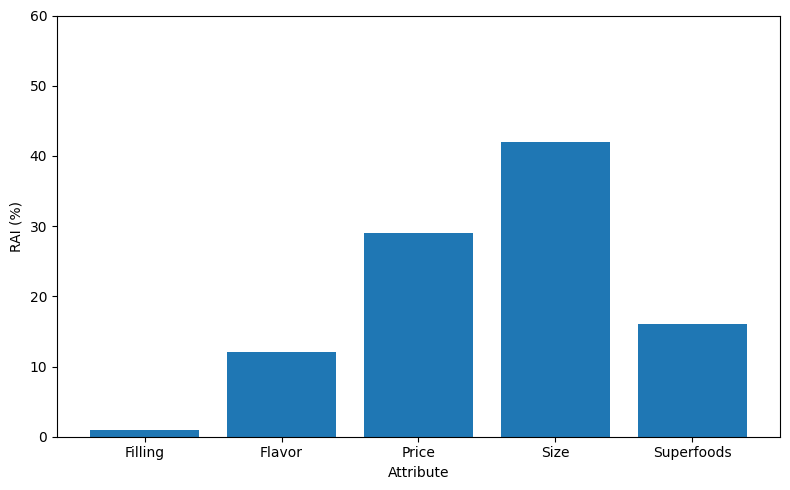

In [67]:
plt.figure(figsize=(8, 5))
plt.bar(RAI['attr'], (RAI['RAI'] * 100).round())
plt.xlabel('Attribute'); plt.ylabel('RAI (%)')
plt.yticks(range(0, 70, 10))
plt.tight_layout(); plt.show()

## Willingness-to-Pay (WTP)

In [70]:
# WTP for Nutty = coef(Nutty) / -coef(Price)
mnl1.params['Nutty'] / -mnl1.params['Price']

0.6717743294613573

In [72]:
# WTP for every coefficient = coef / -coef(Price)
mnl1.params / -mnl1.params['Price']

NONE            -7.080512
Nutty            0.671774
Mixed           -0.171054
Liquid          -0.089771
YesSuperfoods    1.115186
Size10g         -0.266463
Size20g         -2.952457
Size5g          -0.404284
Price           -1.000000
dtype: float64

#### Delta-Method Standard Errors

In [75]:
names = mnl1.names
b = mnl1.params
price_se = mnl1.se[names.index('Price')]
bp = b['Price']
rows = []
for k in names:
    if k == 'Price':
        continue
    wtp = -b[k] / bp
    bk_se = mnl1.se[names.index(k)]
    se_wtp = np.sqrt((bk_se / bp)**2 + (b[k] * price_se / bp**2)**2)
    t = wtp / se_wtp
    p = 2 * (1 - stats.norm.cdf(abs(t)))
    rows.append([k, wtp, se_wtp, t, p])
pd.DataFrame(rows, columns=['var', 'Estimate', 'Std. Error', 't-value', 'Pr(>|t|)']).set_index('var')

,Estimate,Std. Error,t-value,Pr(>|t|)
var,,,,
NONE,-7.080512,0.771821,-9.173775,0.000000e+00
Nutty,0.671774,0.148795,4.514771,6.338509e-06
Mixed,-0.171054,0.156644,-1.091991,2.748372e-01
Liquid,-0.089771,0.120151,-0.747153,4.549710e-01
YesSuperfoods,1.115186,0.149224,7.473218,7.815970e-14
Size10g,-0.266463,0.153986,-1.730429,8.355358e-02
Size20g,-2.952457,0.331886,-8.895986,0.000000e+00
Size5g,-0.404284,0.160910,-2.512477,1.198871e-02


## Market Simulation: Defining Products

In [78]:
# Hypothetical product line for share prediction
products = pd.DataFrame({
    'Product': range(1, 7),
    'Fruity':        [1, 0, 0, 0, 0, 0],
    'Nutty':         [0, 0, 0, 1, 1, 0],
    'Mixed':         [0, 1, 1, 0, 0, 0],
    'Creamy':        [1, 1, 1, 0, 1, 0],
    'Liquid':        [0, 0, 0, 1, 0, 0],
    'NoSuperfoods':  [1, 1, 1, 1, 0, 0],
    'YesSuperfoods': [0, 0, 0, 0, 1, 0],
    'Size5g':        [0, 0, 0, 0, 1, 0],
    'Size10g':       [0, 0, 1, 0, 0, 0],
    'Size15g':       [1, 1, 0, 1, 0, 0],
    'Size20g':       [0, 0, 0, 0, 0, 0],
    'Price':         [6.20, 6.50, 7.10, 7.30, 7.50, 0],
    'NONE':          [0, 0, 0, 0, 0, 1],
})
products

,Product,Fruity,Nutty,Mixed,Creamy,Liquid,NoSuperfoods,YesSuperfoods,Size5g,Size10g,Size15g,Size20g,Price,NONE
0,1,1,0,0,1,0,1,0,0,0,1,0,6.2,0
1,2,0,0,1,1,0,1,0,0,0,1,0,6.5,0
2,3,0,0,1,1,0,1,0,0,1,0,0,7.1,0
3,4,0,1,0,0,1,1,0,0,0,1,0,7.3,0
4,5,0,1,0,1,0,0,1,1,0,0,0,7.5,0
5,6,0,0,0,0,0,0,0,0,0,0,0,0.0,1


## Predict Market Shares

In [81]:
# Utility, exp(utility), and softmax share for each product, using mnl1 coefficients
def predict_mnl(model, data):
    Xp = data[model.names].to_numpy(float)
    utility = Xp @ model.coef
    exp_utility = np.exp(utility)
    share = exp_utility / exp_utility.sum()
    out = data.copy()
    out.insert(0, 'utility', utility)
    out.insert(1, 'exp_utility', exp_utility)
    out.insert(2, 'share', share)
    return out

predict_mnl(mnl1, products)

,utility,exp_utility,share,Product,Fruity,Nutty,Mixed,Creamy,Liquid,NoSuperfoods,YesSuperfoods,Size5g,Size10g,Size15g,Size20g,Price,NONE
0,-4.191192,0.015128,0.224938,1,1,0,0,1,0,1,0,0,0,1,0,6.2,0
1,-4.509624,0.011003,0.163595,2,0,0,1,1,0,1,0,0,0,1,0,6.5,0
2,-5.095351,0.006125,0.091074,3,0,0,1,1,0,1,0,0,1,0,0,7.1,0
3,-4.541357,0.010659,0.158485,4,0,1,0,0,1,1,0,0,0,1,0,7.3,0
4,-4.135303,0.015998,0.237868,5,0,1,0,1,0,0,1,1,0,0,0,7.5,0
5,-4.786417,0.008342,0.124040,6,0,0,0,0,0,0,0,0,0,0,0,0.0,1


### Findings

- Size is the biggest driver of choice accounting for roughly 42% of the decision. Customers clearly prefer the 15g size, and I found the large 20g size to be a real turn-off; we might have to incentivise it (eg: discounts) for it to sell well

- Price is the second biggest factor, at about 29%, and I see clear price sensitivity

- The strongest single feature I found is "superfoods." It's the biggest positive in the whole study customers would pay roughly €1.12 more for it. I see this as a genuine premium opportunity and a clear point of differentiation worth marketing.

- On flavor, nutty is the favorite. Customers would pay about €0.67 more for nutty over the standard fruity option. By contrast, I found that other choices like mixed flavor and liquid filling made little difference, so I wouldn't invest much there.
